# 问卷数据

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
from collections import defaultdict
from matplotlib.font_manager import FontProperties
from wordcloud import WordCloud
from collections import Counter
import re
import jieba

font = FontProperties(fname=font_path, size=14)
title_font = FontProperties(fname=font_path, size=12)
label_font = FontProperties(fname=font_path, size=10)
ticks_font = FontProperties(fname=font_path, size=9)

def parse_content(content_str):
    try:
        return json.loads(content_str)
    except json.JSONDecodeError:
        try:
            # Attempt to fix common JSON issues
            fixed_content = content_str.replace("'", '"').replace("True", "true").replace("False", "false")
            return json.loads(fixed_content)
        except:
            return {'list': []}
    except TypeError:
        return {'list': []}

# Function to clean Chinese text
def clean_chinese_text(text):
    # Remove non-Chinese characters except basic punctuation
    cleaned = re.sub(r'[^\u4e00-\u9fa5，。！？、：；“”‘’（）【】《》\s]', '', text)
    # Remove extra spaces
    return re.sub(r'\s+', ' ', cleaned).strip()

survey_df = pd.read_csv(
    '/home/mzyy1001/business/data/2025-05-31-10-01-50_EXPORT_CSV_19470858_516_ds_survey_feedback_0.csv',
    encoding='utf-8',
    on_bad_lines='skip'
)
survey_id = 1000004
survey_df = survey_df[survey_df['survey_id']==survey_id]

# Data structure: 
# {survey_id: {sub_survey_id: {uniqueId: {type: str, question: str, answers: dict/text_responses}}}}
results = defaultdict(lambda:defaultdict(lambda: defaultdict(lambda: {
    'type': '',
    'question': '',
    'answers': defaultdict(int),
    'text_responses': []
})))

/tmp/ipykernel_649904/2422736928.py:37: DtypeWarning: Columns (0: sales_id) have mixed types. Specify dtype option on import or set low_memory=False.
  survey_df = pd.read_csv(


In [3]:
survey_groups = survey_df.groupby('sub_survey_id')

for sub_survey_id, group in survey_groups:
    print(f"\nProcessing Sub-Survey ID: {sub_survey_id}")
    print(f"Number of Responses: {len(group)}")
    
    # Process each response in the group
    for idx, row in group.iterrows():
        content = parse_content(row['content'])
        questions = content.get('list', [])
        
        for question in questions:
            if 'uniqueId' not in question or 'question' not in question or 'type' not in question:
                print(f"Skipping malformed question in response {idx} of sub-survey {sub_survey_id}")
                continue
            
            unique_id = question['uniqueId']
            q_type = question['type']
            q_text = question['question']

            if q_type=='type':
                pass
            
            # print(f"Question ID: {unique_id}, Type: {q_type}, Text: {q_text}")
            

            # Initialize question entry if first encounter
            if not results[survey_id][sub_survey_id][unique_id]['question']:
                results[survey_id][sub_survey_id][unique_id] = {
                    'type': q_type,
                    'question': q_text,
                    'answers': defaultdict(int),
                    'text_responses': []
                }

            # Process based on question type
            if q_type in ['single', 'mul']:
                # Process choice-based questions
                if 'answers' in question:
                    for answer in question['answers']:
                        if answer.get('selected', False):
                            answer_text = answer.get('text', '')
                            results[survey_id][sub_survey_id][unique_id]['answers'][answer_text] += 1
        
            elif q_type == 'text':
                # Process text responses
                text_response = ""
                if 'answers' in question:
                    for answer in question['answers']:
                        if 'text' in answer:
                            text_response += answer['text'] + " "
                    text_response = text_response.strip()
                
                if text_response:
                    # Clean and store text response
                    cleaned_text = clean_chinese_text(text_response)
                    if cleaned_text:
                        results[survey_id][sub_survey_id][unique_id]['text_responses'].append(cleaned_text)


Processing Sub-Survey ID: 1.0
Number of Responses: 27847

Processing Sub-Survey ID: 2.0
Number of Responses: 3481

Processing Sub-Survey ID: 3.0
Number of Responses: 3433

Processing Sub-Survey ID: 4.0
Number of Responses: 3458

Processing Sub-Survey ID: 5.0
Number of Responses: 3498

Processing Sub-Survey ID: 6.0
Number of Responses: 20990

Processing Sub-Survey ID: 7.0
Number of Responses: 1323

Processing Sub-Survey ID: 8.0
Number of Responses: 1415

Processing Sub-Survey ID: 9.0
Number of Responses: 1423

Processing Sub-Survey ID: 10.0
Number of Responses: 1383

Processing Sub-Survey ID: 11.0
Number of Responses: 1391


In [6]:
from tqdm import tqdm
import json
import re

from peft import PeftModel, PeftConfig

sub_surveys = [8.0, 9.0]

for survey_id, sub_survey in results.items():
    for sub_survey_id, questions in sub_survey.items():
        if sub_survey_id not in sub_surveys:
            continue

        for _, data in tqdm(questions.items(), desc=f"Processing Survey {survey_id}-{sub_survey_id}"):
            q_type = data['type']
            option_list = []
            if q_type in ['single', 'mul']:
                question_text = data['question']
                
                if '年龄' in question_text or '常驻' in question_text:
                    continue  # 跳过人口统计问题
                
                # 获取真实答案分布
                true_counts = data['answers']

                print(f"Question ID: {unique_id}, Type: {q_type}, Text: {question_text}")
                print(f"True Answer Distribution: {true_counts}")

/home/mzyy1001/business/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Processing Survey 1000004-8.0: 100%|██████████| 7/7 [00:00<00:00, 50102.61it/s]


Question ID: qsingle_6, Type: single, Text: 您是否知道肠胃感冒?
True Answer Distribution: defaultdict(<class 'int'>, {'是': 890, '否': 525})
Question ID: qsingle_6, Type: single, Text: 请问您认为哪个季节容易发生肠胃感冒?
True Answer Distribution: defaultdict(<class 'int'>, {'全年': 232, '夏': 263, '冬': 123, '秋': 119, '春': 153})
Question ID: qsingle_6, Type: single, Text: 请问您发生肠胃感冒的场景往往是? 
True Answer Distribution: defaultdict(<class 'int'>, {'冷热刺激(高温乘凉不当、猛吹空调等)': 303, '天气变化大': 157, '饮食不良(喜吃辛辣、冰饮等)': 275, '病毒感染': 138, '其他': 17})
Question ID: qsingle_6, Type: single, Text: 您一般用什么方法来缓解肠胃感冒症状?
True Answer Distribution: defaultdict(<class 'int'>, {'联合用药': 168, '藿香正气类产品': 470, '抗病毒用药': 154, '不在意': 90, '其他': 8})
Question ID: qsingle_6, Type: single, Text: 您是否会购买太极藿香正气口服液解决这些症状
True Answer Distribution: defaultdict(<class 'int'>, {'是': 416, '否': 53})


Processing Survey 1000004-9.0: 100%|██████████| 7/7 [00:00<00:00, 57232.22it/s]

Question ID: qsingle_6, Type: single, Text: 您过去一年内是否有湿气重的症状(身体沉重、精神不振、皮肤问题等)?
True Answer Distribution: defaultdict(<class 'int'>, {'是': 884, '否': 539})
Question ID: qsingle_6, Type: single, Text: 请问您觉得产生湿气的原因是? 
True Answer Distribution: defaultdict(<class 'int'>, {'体质问题': 183, '久坐不运动': 248, '爱吃冷饮、火锅': 269, '环境潮湿': 170, '其他': 14})
Question ID: qsingle_6, Type: single, Text: 您觉得湿气重更容易发生在哪个季节?
True Answer Distribution: defaultdict(<class 'int'>, {'夏': 254, '秋': 100, '春': 152, '全年': 258, '冬': 120})
Question ID: qsingle_6, Type: single, Text: 您一般用什么方法来缓解湿气重的症状?
True Answer Distribution: defaultdict(<class 'int'>, {'不在意': 176, '饮食调理': 327, '刮痧、蒸桑拿、运动等': 303, '对症中药': 77})
Question ID: qsingle_6, Type: single, Text: 您是否会购买太极藿香正气口服液解决这些症状
True Answer Distribution: defaultdict(<class 'int'>, {'是': 61, '否': 16})


# 社交媒体数据

In [10]:
import pandas as pd

# Load the data
social_df = pd.read_csv('/home/mzyy1001/business/data/taiji_all.csv')

import re

import pandas as pd

# 确保 content_desc 列是字符串类型
social_df['content_desc'] = social_df['content_desc'].astype(str)
social_df['author_name'] = social_df['author_name'].astype(str)
social_df['content_desc'] = social_df['content_desc'].apply(lambda x: re.sub(r'#.*?#', '', str(x)))

filter_df_xhs = social_df[
    (social_df['data_channel'] == '小红书') &
    (social_df['content_desc'].str.len() < 200) &
    (social_df['content_desc'].str.contains('藿香正气')) &
    ~(social_df['content_desc'].str.contains('藿香茶')) &
    ~(social_df['content_desc'].str.contains('廣藿香')) &
    ~(social_df['author_name'].str.contains('医')) &
    ~(social_df['author_name'].str.contains('药')) &
    ~(social_df['author_name'].str.contains('疗')) &
    ~(social_df['author_name'].str.contains('健康')) &
    ~(social_df['author_name'].str.contains('养生')) &
    ~(social_df['content_desc'].str.contains('育儿')) &
    ~(social_df['content_desc'].str.contains('@')) &
    ~(social_df['content_desc'].str.contains('藿香鱼'))
].reset_index(drop=True)

filter_df_wb = social_df[
    (social_df['data_channel'] == '微博') &
    (social_df['content_desc'] != '转发微博') &
    (social_df['content_desc'].str.len() > 5) &
    (social_df['content_desc'].str.contains('藿香正气')) &
    ~(social_df['content_desc'].str.contains('藿香茶')) &
    ~(social_df['content_desc'].str.contains('廣藿香')) &
    ~(social_df['author_name'].str.contains('医')) &
    ~(social_df['author_name'].str.contains('药')) &
    ~(social_df['author_name'].str.contains('疗')) &
    ~(social_df['author_name'].str.contains('健康')) &
    ~(social_df['author_name'].str.contains('养生')) &
    ~(social_df['content_desc'].str.contains('育儿')) &
    ~(social_df['content_desc'].str.contains('@')) &
    ~(social_df['content_desc'].str.contains('藿香鱼'))  # 使用 ~ 表示不包含藿香茶
].reset_index(drop=True) #[['create_time', 'content_desc', 'pred_province']]

filter_df_jd = social_df[
    (social_df['data_channel'] == '京东') &
    (social_df['content_desc'].str.contains('藿香正气')) &
    ~(social_df['content_desc'].str.contains('藿香茶')) &
    ~(social_df['content_desc'].str.contains('廣藿香')) &
    ~(social_df['author_name'].str.contains('医')) &
    ~(social_df['author_name'].str.contains('药')) &
    ~(social_df['author_name'].str.contains('疗')) &
    ~(social_df['author_name'].str.contains('健康')) &
    ~(social_df['author_name'].str.contains('养生')) &
    ~(social_df['content_desc'].str.contains('育儿')) &
    ~(social_df['content_desc'].str.contains('@')) &
    ~(social_df['content_desc'].str.contains('藿香鱼'))  # 使用 ~ 表示不包含藿香茶
].reset_index(drop=True) #[['create_time', 'content_desc', 'pred_province']]

filter_df_tb = social_df[
    (social_df['data_channel'] == '淘宝') &
    (social_df['content_desc'].str.contains('藿香正气')) &
    ~(social_df['content_desc'].str.contains('藿香茶')) &
    ~(social_df['content_desc'].str.contains('廣藿香')) &
    ~(social_df['author_name'].str.contains('医')) &
    ~(social_df['author_name'].str.contains('药')) &
    ~(social_df['author_name'].str.contains('疗')) &
    ~(social_df['author_name'].str.contains('健康')) &
    ~(social_df['author_name'].str.contains('养生')) &
    ~(social_df['content_desc'].str.contains('育儿')) &
    ~(social_df['content_desc'].str.contains('@')) &
    ~(social_df['content_desc'].str.contains('藿香鱼'))  # 使用 ~ 表示不包含藿香茶
].reset_index(drop=True) #[['create_time', 'content_desc', 'pred_province']]

filter_df = pd.concat([filter_df_xhs, filter_df_wb], ignore_index=True)

# filter_df = filter_df.dropna(subset=['pred_province'])

# Drop duplicates: treat texts with 10 consecutive same characters as duplicates
def get_10char_substrings(text):
    """Extract all 10-character substrings from a text"""
    if len(text) < 10:
        return set()
    substrings = set()
    for i in range(len(text) - 9):
        substrings.add(text[i:i+10])
    return substrings

print(f"Before deduplication: {len(filter_df)} rows")

# First, do exact duplicate removal
filter_df = filter_df.drop_duplicates(subset=['content_desc'])
print(f"After exact duplicate removal: {len(filter_df)} rows")

# Then, remove duplicates based on 10-character overlap
# Create a set to track seen 10-character substrings
seen_substrings = set()
indices_to_keep = []

for idx, row in filter_df.iterrows():
    text = str(row['content_desc'])
    substrings = get_10char_substrings(text)
    
    # Check if any substring has been seen before
    if substrings and substrings.intersection(seen_substrings):
        # This text has 10 consecutive characters in common with a previous text
        continue
    
    # Mark all substrings as seen and keep this row
    seen_substrings.update(substrings)
    indices_to_keep.append(idx)

filter_df = filter_df.loc[indices_to_keep].reset_index(drop=True)
print(f"After 10-char deduplication: {len(filter_df)} rows")

/tmp/ipykernel_649904/2658546170.py:4: DtypeWarning: Columns (0: tenant_name, 1: data_channel, 2: session_id, 3: biz_id, 4: create_time, 5: item_title, 6: author_id, 7: author_name, 8: author_profile_images, 9: content, 10: content_title, 11: content_desc, 12: content_hashtag, 13: device, 14: voc_url, 15: image_urls, 16: vedio_urls, 17: pred_province, 18: ref_nick_name, 19: ref_content, 20: ref_content_desc, 21: ref_voc_url) have mixed types. Specify dtype option on import or set low_memory=False.
  social_df = pd.read_csv('/home/mzyy1001/business/data/taiji_all.csv')


Before deduplication: 65768 rows
After exact duplicate removal: 54349 rows
After 10-char deduplication: 27838 rows


In [6]:
filter_df = filter_df.reset_index(drop=True)

In [7]:
filter_df[['content_desc', 'pred_province', 'create_time','data_channel']] \
    .sort_values(by='create_time', ascending=True) \
    .reset_index(drop=True)

,content_desc,pred_province,create_time,data_channel
0,♦中医笔记♦保济丸和藿香正气水\n效果差不多。受不了藿香正气水的可以用保济丸。,NaN,2019-03-23 23:37:40,小红书
1,前几天不舒服去看了医生，说我中暑了拿点藿香正气胶囊吃就好了，自从吃了它我就更难受了，吃过它坚...,NaN,2020-05-22 22:31:03,小红书
2,然鹅实在是有点体力不支\n昨天一天只有晚上到家吃了煎鱼\n然后过了半个小时狂吐\n老公买了藿...,NaN,2020-05-28 08:01:14,小红书
3,【暑热+内湿】夏天的正气水\n藿香正气，解表化湿，祛除湿浊\n🌸藿香正气水的日常使用方法：\...,NaN,2020-06-28 21:49:44,小红书
4,🌟大家一直在催的军训必备好物合集终于来惹！我是不是有点晚了！\n✨防晒\n💫面部：资生堂蓝胖...,NaN,2020-08-24 19:24:04,小红书
...,...,...,...,...
27833,我女儿发烧39℃\n推天河水10分钟\n还用藿香正气水做的脐疗\n退烧，睡了 ​​​,黑龙江,2023-12-20 21:15:04,微博
27834,胃痛（其实也不知道到底是不是胃）晚上忍痛坚持两小时忙完孩子和家务 想起藿香正气 赶紧吃了四粒...,江苏,2023-12-20 22:25:58,微博
27835,藿香正气水？等会儿睡前还得来一支[裂开] ​,重庆,2023-12-20 22:27:12,微博
27836,藿香正气水 喝一口 yue一天 ​​​,内蒙古,2023-12-20 22:39:12,微博


In [12]:
# save the filter_df
filter_df.to_csv('/home/mzyy1001/business/data/1_filter_df.csv', index=False)

## 实验

In [14]:
import pandas as pd

filter_df = pd.read_csv('/home/mzyy1001/business/data/1_filter_df.csv')

### 1. 对社交媒体数据进行聚类

对所有评论生成 embedding

使用 HDBSCAN 聚类

自动识别哪些簇是无意义噪声（通常密度低、离群点）

仅保留主簇作为“有意义评论”

📌 HDBSCAN 有一个天然优势➡会给出“low probability points”作为噪声。

In [ ]:
from sklearn.cluster import HDBSCAN
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
# UMAP will be imported dynamically (GPU cuML or CPU version)

# Load Chinese sentence transformer model
print("Loading sentence transformer model...")
# model path is /data/houwanlong/models/iic/nlp_corom_sentence-embedding_chinese-base-medical
model = SentenceTransformer('/home/mzyy1001/business/model/nlp_corom_sentence-embedding_chinese-base-medical')
print("Model loaded successfully!")


Loading sentence transformer model...


/home/mzyy1001/business/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


FileNotFoundError: Path /data/houwanlong/models/iic/nlp_corom_sentence-embedding_chinese-base-medical not found

In [10]:
# Generate embeddings for social media comments
print(f"Total comments to process: {len(filter_df)}")
print("Generating embeddings...")

# Get all comments
comments = filter_df['content_desc'].tolist()

# Generate embeddings in batches to avoid memory issues
batch_size = 100
embeddings = []

for i in tqdm(range(0, len(comments), batch_size), desc="Generating embeddings"):
    batch = comments[i:i+batch_size]
    batch_embeddings = model.encode(batch, show_progress_bar=False)
    embeddings.extend(batch_embeddings)

embeddings = np.array(embeddings)
print(f"Embeddings shape: {embeddings.shape}")


Total comments to process: 27838
Generating embeddings...


Generating embeddings: 100%|██████████| 279/279 [00:35<00:00,  7.95it/s]


Embeddings shape: (27838, 768)


In [11]:
# Optional: Reduce dimensionality with UMAP for better clustering
# This can help with high-dimensional embeddings
print("Reducing dimensionality with UMAP...")
from umap import UMAP
umap_reducer = UMAP(n_components=50, random_state=42, n_neighbors=15, min_dist=0.0, verbose=True, n_jobs=-1)
embeddings_reduced = umap_reducer.fit_transform(embeddings)
print(f"Reduced embeddings shape: {embeddings_reduced.shape}")

Reducing dimensionality with UMAP...


/data/anaconda3/envs/med_rec/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(min_dist=0.0, n_components=50, n_jobs=1, random_state=42, verbose=True)
Wed Dec  3 07:28:43 2025 Construct fuzzy simplicial set
Wed Dec  3 07:28:43 2025 Finding Nearest Neighbors
Wed Dec  3 07:28:43 2025 Building RP forest with 13 trees
Wed Dec  3 07:28:47 2025 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	 5  /  15
	 6  /  15
	 7  /  15
	Stopping threshold met -- exiting after 7 iterations
Wed Dec  3 07:29:00 2025 Finished Nearest Neighbor Search
Wed Dec  3 07:29:03 2025 Construct embedding


Epochs completed:   2%| ▎          5/200 [00:00]

	completed  0  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  91%| █████████  182/200 [00:26]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:29]


Wed Dec  3 07:29:58 2025 Finished embedding
Reduced embeddings shape: (27838, 50)


In [12]:
# Apply HDBSCAN clustering
print("Applying HDBSCAN clustering...")
clusterer = HDBSCAN(
    min_cluster_size=50,  # Minimum points in a cluster
    min_samples=50,        # Minimum samples in neighborhood
    cluster_selection_epsilon=0.1,  # Distance threshold for cluster selection
    metric='euclidean',
    cluster_selection_method='eom'  # 'eom' or 'leaf'
)

cluster_labels = clusterer.fit_predict(embeddings_reduced)

# -1 indicates noise/outlier points
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)

print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise} ({n_noise/len(cluster_labels)*100:.2f}%)")
print(f"Number of clustered points: {len(cluster_labels) - n_noise} ({(len(cluster_labels) - n_noise)/len(cluster_labels)*100:.2f}%)")


Applying HDBSCAN clustering...


Number of clusters found: 52
Number of noise points: 14826 (53.26%)
Number of clustered points: 13012 (46.74%)


In [13]:
# Add cluster labels to dataframe
filter_df['cluster_label'] = cluster_labels
filter_df['is_noise'] = (cluster_labels == -1)

# Analyze cluster sizes
cluster_sizes = Counter(cluster_labels)
print("\nCluster size distribution:")
for cluster_id, size in sorted(cluster_sizes.items()):
    if cluster_id == -1:
        print(f"  Noise: {size} points")
    else:
        print(f"  Cluster {cluster_id}: {size} points")



Cluster size distribution:
  Noise: 14826 points
  Cluster 0: 183 points
  Cluster 1: 198 points
  Cluster 2: 54 points
  Cluster 3: 147 points
  Cluster 4: 101 points
  Cluster 5: 58 points
  Cluster 6: 51 points
  Cluster 7: 64 points
  Cluster 8: 411 points
  Cluster 9: 117 points
  Cluster 10: 89 points
  Cluster 11: 102 points
  Cluster 12: 65 points
  Cluster 13: 189 points
  Cluster 14: 367 points
  Cluster 15: 159 points
  Cluster 16: 574 points
  Cluster 17: 50 points
  Cluster 18: 187 points
  Cluster 19: 139 points
  Cluster 20: 207 points
  Cluster 21: 143 points
  Cluster 22: 405 points
  Cluster 23: 219 points
  Cluster 24: 102 points
  Cluster 25: 182 points
  Cluster 26: 796 points
  Cluster 27: 67 points
  Cluster 28: 328 points
  Cluster 29: 63 points
  Cluster 30: 50 points
  Cluster 31: 95 points
  Cluster 32: 551 points
  Cluster 33: 285 points
  Cluster 34: 492 points
  Cluster 35: 181 points
  Cluster 36: 109 points
  Cluster 37: 678 points
  Cluster 38: 188 poi

Creating 2D visualization...
UMAP(min_dist=0.0, n_jobs=1, random_state=42, verbose=True)
Wed Dec  3 07:30:17 2025 Construct fuzzy simplicial set
Wed Dec  3 07:30:17 2025 Finding Nearest Neighbors
Wed Dec  3 07:30:17 2025 Building RP forest with 13 trees


/data/anaconda3/envs/med_rec/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Wed Dec  3 07:30:17 2025 NN descent for 15 iterations
	 1  /  15


	 2  /  15
	Stopping threshold met -- exiting after 2 iterations
Wed Dec  3 07:30:18 2025 Finished Nearest Neighbor Search
Wed Dec  3 07:30:18 2025 Construct embedding


Epochs completed:   4%| ▍          9/200 [00:00]

...

Epochs completed:  93%| █████████▎ 186/200 [00:08]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:09]
/tmp/ipykernel_1841719/1404659447.py:23: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()


Wed Dec  3 07:31:12 2025 Finished embedding


/data/anaconda3/envs/med_rec/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


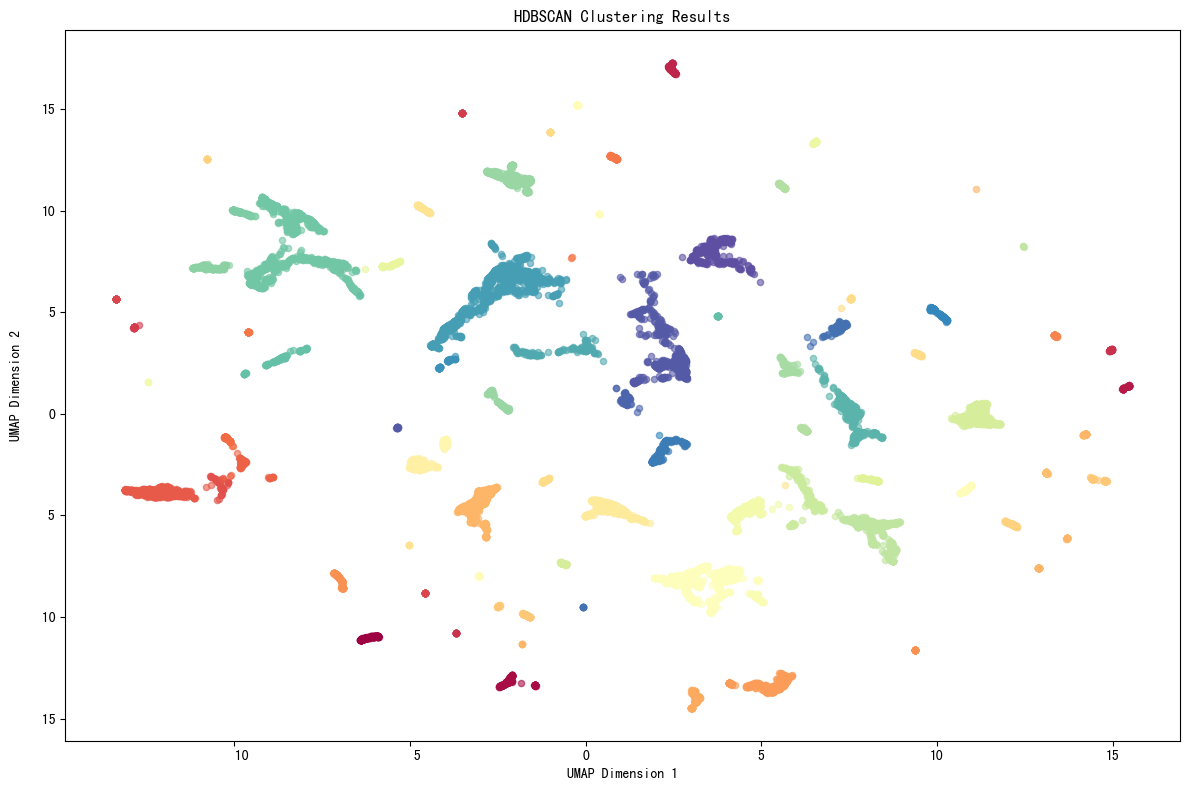

In [14]:
# Visualize clusters using 2D UMAP
print("Creating 2D visualization...")
from umap import UMAP
umap_2d = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.0, verbose=True, n_jobs=-1)
embeddings_2d = umap_2d.fit_transform(embeddings_reduced)

plt.figure(figsize=(12, 8))
# Only show non-noise clusters
unique_labels = [k for k in set(cluster_labels) if k != -1]
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    marker = 'o'
    alpha = 0.6
    
    class_member_mask = (cluster_labels == k)
    xy = embeddings_2d[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, alpha=alpha, s=20)

plt.title('HDBSCAN Clustering Results', fontproperties=title_font)
plt.xlabel('UMAP Dimension 1', fontproperties=label_font)
plt.ylabel('UMAP Dimension 2', fontproperties=label_font)
plt.tight_layout()
plt.show()


In [15]:
# Display sample comments from each cluster
print("\n" + "="*80)
print("Sample comments from each cluster:")
print("="*80)

for cluster_id in sorted(set(cluster_labels)):
    if cluster_id == -1:
        print(f"\n【Noise Points】({cluster_sizes[cluster_id]} points)")
    else:
        print(f"\n【Cluster {cluster_id}】({cluster_sizes[cluster_id]} points)")
    
    cluster_comments = filter_df[filter_df['cluster_label'] == cluster_id]['content_desc'].tolist()
    sample_size = min(5, len(cluster_comments))
    samples = np.random.choice(cluster_comments, size=sample_size, replace=False)
    
    for i, comment in enumerate(samples, 1):
        print(f"  {i}. {comment[:100]}..." if len(comment) > 100 else f"  {i}. {comment}")



Sample comments from each cluster:

【Noise Points】(14826 points)
  1.  今天实在是太热了，闷热闷热的,下次得准备藿香正气胶囊了，头都有点晕
  2. 上周五早上起来没力气，灌了碗五虎汤，吐出去感觉好多了，当天有点发烧，膝盖疼，去医院搁愣搁愣嗓子报告出来阳了  藿香正气水敷肚脐，吃了片感康睡醒就好了  第二天想吃点垃圾，打电话给虾锅，不营业，叫了份麻...
  3.  我只是看一下电视上的吊桥晃动 就眩晕想吐的人 我舅以为我中暑了 硬灌两瓶藿香正气水  没法想象这样倒吊旋转  而且这么多次 就为了一个一秒的镜头  这不是简单的努力了 这简直是拼命三郎了  王一博 ...
  4. 中午吃了单位食堂的茶树菇后就出现恶心想吐的感觉，吃了一袋儿藿香正气滴丸，症状不见好转！[摊手]
我是不是茶树菇中毒了？[费解] ​​​
  5. 成长就是 半夜突然吐了以后 你会选择主动给自己灌一只藿香正气水 虽然但是居然真的好受了一些 [吐] ​

【Cluster 0】(183 points)
  1. 太极集团 藿香味小雪糕～
口感就是藿香正气水一样的药味，
不甜还挺好吃～  ​​​
  2. 夏日解暑必备冰糕，绿豆水，藿香正气水等神器！越来越热了，需要随时解解暑！ ​
  3. 藿香正气水味的雪糕哎 ​​​
  4. 高温天气
来根藿香正气味雪糕
透心凉，心飞扬
有颜又有料
味道巴适的很 ​​​
  5. 藿香正气水雪糕无法接受真的无法接受，蹭吃蹭喝的一天，如果领导不问我为什么不去加班就更完美了[苦涩] ​

【Cluster 1】(198 points)
  1. 爱心小药箱，方便你我他

近日大庆西站客运服务台更新了爱心小药箱的一些日常用药，比如：血压计、速效救心丸、藿香正气胶囊、烫伤膏以及晕车药等，受到了旅客们的一致好评。爱心药箱，情暖万家，愿每一位旅客都能...
  2. 【德阳高新区：“小”创新“大”效益 “五小”活动助发展提动力】近日，2023年德阳高新区职工“五小”活动创新成果征集活动评选出20项创新成果，其中由四川依科制药有限公司完成的“全自动藿香正气水理瓶机”...
  3.  入夏以来，高温不断，为让环卫工人感受到丝丝清凉和关心关爱，连月来，简阳市综合行政执法局持续组织环卫企业向环卫工人发放夏

In [16]:
# Filter out noise and keep only meaningful clusters
meaningful_df = filter_df[filter_df['is_noise'] == False].copy()

print(f"\nOriginal comments: {len(filter_df)}")
print(f"Meaningful comments (after removing noise): {len(meaningful_df)}")
print(f"Noise removed: {len(filter_df) - len(meaningful_df)} ({((len(filter_df) - len(meaningful_df))/len(filter_df)*100):.2f}%)")

# Summary by cluster
print("\nMeaningful clusters summary:")
cluster_summary = meaningful_df.groupby('cluster_label').agg({
    'content_desc': 'count',
    'data_channel': lambda x: x.value_counts().to_dict()
}).rename(columns={'content_desc': 'count'})

for cluster_id, row in cluster_summary.iterrows():
    print(f"\nCluster {cluster_id}: {row['count']} comments")
    print(f"  Channels: {row['data_channel']}")



Original comments: 27838
Meaningful comments (after removing noise): 13012
Noise removed: 14826 (53.26%)

Meaningful clusters summary:

Cluster 0: 183 comments
  Channels: {'微博': 162, '小红书': 21}

Cluster 1: 198 comments
  Channels: {'微博': 183, '小红书': 15}

Cluster 2: 54 comments
  Channels: {'微博': 51, '小红书': 3}

Cluster 3: 147 comments
  Channels: {'微博': 147}

Cluster 4: 101 comments
  Channels: {'微博': 101}

Cluster 5: 58 comments
  Channels: {'微博': 33, '小红书': 25}

Cluster 6: 51 comments
  Channels: {'微博': 47, '小红书': 4}

Cluster 7: 64 comments
  Channels: {'小红书': 53, '微博': 11}

Cluster 8: 411 comments
  Channels: {'微博': 264, '小红书': 147}

Cluster 9: 117 comments
  Channels: {'小红书': 67, '微博': 50}

Cluster 10: 89 comments
  Channels: {'小红书': 55, '微博': 34}

Cluster 11: 102 comments
  Channels: {'小红书': 54, '微博': 48}

Cluster 12: 65 comments
  Channels: {'微博': 63, '小红书': 2}

Cluster 13: 189 comments
  Channels: {'微博': 185, '小红书': 4}

Cluster 14: 367 comments
  Channels: {'微博': 348, '小红书': 19

In [17]:
meaningful_df[['content_desc', 'pred_province', 'create_time','data_channel','cluster_label']] \
    .sort_values(by='create_time', ascending=True) \
    .reset_index(drop=True)

,content_desc,pred_province,create_time,data_channel,cluster_label
0,【暑热+内湿】夏天的正气水\n藿香正气，解表化湿，祛除湿浊\n🌸藿香正气水的日常使用方法：\...,NaN,2020-06-28 21:49:44,小红书,20
1,🌟大家一直在催的军训必备好物合集终于来惹！我是不是有点晚了！\n✨防晒\n💫面部：资生堂蓝胖...,NaN,2020-08-24 19:24:04,小红书,45
2,终于收到7月份的快递了[笑哭R]\n结果是史上最难喝的饮料[石化R]大家不要踩坑啊！\n稀释...,NaN,2020-09-01 20:33:27,小红书,16
3,作为一个重度咖啡爱好者，每次看到新品都想尝试，虽然每次尝试几乎都踩雷。这次也不例外，附近便利...,NaN,2020-11-25 13:02:08,小红书,16
4,第一次喝可乐桶是用的杰克丹尼7⃣️号\n第二次和野葛经典款搭配滴 味道绝了[叹气R]\n总结...,NaN,2021-03-03 01:41:45,小红书,17
...,...,...,...,...,...
13007,藿香正气水真nb 用两支兑热水泡了一会脚然后喝了一支之后好多了,吉林,2023-12-20 19:09:26,微博,8
13008,下班到家弟弟高烧39.9，爸爸用西医吃退烧药\n我用藿香正气水棉花塞肚脐+推胳膊+湿毛巾敷额...,上海,2023-12-20 19:57:43,微博,40
13009,我女儿发烧39℃\n推天河水10分钟\n还用藿香正气水做的脐疗\n退烧，睡了 ​​​,黑龙江,2023-12-20 21:15:04,微博,40
13010,藿香正气水？等会儿睡前还得来一支[裂开] ​,重庆,2023-12-20 22:27:12,微博,3


In [ ]:
# save the meaningful_df
meaningful_df.to_csv('/home/houwanlong/survey_2025/exps/12.01-12.05/data/2_meaningful_df.csv', index=False)

In [10]:
meaningful_df = pd.read_csv('/home/houwanlong/survey_2025/exps/12.01-12.05/data/2_meaningful_df.csv')

### 使用LLM根据问题对每个问题打标，判断该cluster对问卷问题是否有意义

#### SSR实现

Step A：对所有 cluster 做 topic summary + relevance（只做一次，不依赖问卷问题）
Step B：对每个问卷问题生成 anchors
Step C：对所有 cluster 的 topic 与该问卷题目做 SSR → 得到 topic-level 方向（权重）
Step D：对 cluster 内所有评论做 SSR → 得到 raw cluster pmf
Step E：根据 relevance / 你自己设置的规则决定保留哪些 cluster
Step F：根据权重做 weighted aggregation → 得到 predicted pmf

In [11]:
import numpy as np

# ----------------------------
# 1. Cosine similarity
# ----------------------------
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)

# ----------------------------
# 2. SSR 核心函数
# ----------------------------
def ssr_score(text: str, encoder, anchor_embeddings):
    """
    text: 待量化评论
    encoder: 一个函数，输入文本 -> 输出 embedding
    anchor_embeddings: 长度为 len(anchor_embeddings) 的 list，每个是一个 anchor 的 embedding
    
    返回:
        pmf: 概率分布 (长度为 len(anchor_embeddings))
        mean_score: 加权平均得分 (1~len(anchor_embeddings))
    """

    # 编码文本
    v = encoder.encode(text)

    # 与anchors 计算 cosine
    sims = np.array([cosine_sim(v, a) for a in anchor_embeddings], dtype=float)

    # min-subtraction
    sims = sims - sims.min()

    # 避免全 0
    if sims.sum() == 0:
        sims += 1e-8

    # 归一化得到 pmf
    pmf = sims / sims.sum()

    # mean (1~5)
    mean_score = np.dot(np.arange(1, len(anchor_embeddings)+1), pmf)

    return pmf, mean_score

In [12]:
relevance_prompt_template = '''
你是一名用户调研分析专家。

我会给你一组来自同一个语义簇（cluster）的主题，以及一个问卷题目。
请你判断该 cluster 的主题是否与该问卷题目所测量的内容相关。

请严格按以下 JSON 格式输出（注意字段和值都必须一致）：

{{
  "is_relevant": "相关 或 不相关"
}}

判断原则（非常重要）：
- 只要评论内容能表达对问卷题目所测维度的看法、情绪、态度或体验，即视为“相关”。
- 如果评论是闲聊、吐槽客服、物流、活动、广告、无意义文本、表情或与产品评价无关，则视为“不相关”。
- 判断基于该 cluster 的整体趋势，而不是个别评论。

下面是问卷题目：
{QUESTION}

下面是问卷题目可供选择的答案：
{OPTIONS}

下面是该 cluster 的主题：
{CLUSTER_TOPIC}

请严格按以下 JSON 格式输出：
{{
  "is_relevant": "相关 或 不相关"
}}
'''

topic_only_prompt = '''
你是一名用户调研分析专家。

我会给你一组来自同一个语义簇（cluster）的用户评论。
请你用一句话描述该 cluster 的主题（基于整体内容，而不是个别评论）。

请严格按以下 JSON 格式输出（注意字段和值都必须一致）：

{{
  "cluster_topic": "<一句话主题描述>"
}}

下面是该 cluster 的评论（每条之间用换行分隔）：
{CLUSTER_COMMENTS}

请严格按以下 JSON 格式输出：
{{
  "cluster_topic": "<一句话主题描述>"
}}
'''

anchor_prompt = '''
你是一名专业的问卷语义建模专家。

我会给你一个问卷题目和该题目的所有选项。
你的任务是为每个选项生成一个 "语义锚点句子（anchor sentence）"。

要求：
1. 每个锚点句子必须是自然语言表达，而不是重复选项文本本身。
2. 每个锚点必须清晰表达该选项所代表的态度或立场。
3. 锚点句子要尽可能具体、生动、带情绪或明确倾向（方便进行语义相似度计算）。
4. 输出顺序必须与选项顺序完全一致。
5. 锚点句子越像真实用户说的话越好。

请严格按以下 JSON 格式输出：
{{
  "anchors": [
    "<对应选项1 的 anchor sentence>",
    "<对应选项2 的 anchor sentence>",
    ...
  ]
}}

下面是问卷题目：
{QUESTION}

下面是该题目的选项（按顺序）：
{OPTIONS}
'''

In [13]:
import openai
import json

base_url = "http://0.0.0.0:8071/v1"
api_key = "EMPTY"
model_id = "/data/whp/models/qwen3/Qwen3-8B"

client = openai.OpenAI(base_url=base_url, api_key=api_key)

In [ ]:
# ---------------------------------------------------
# Step A：cluster topic（只做一次，不含 relevance）
# ---------------------------------------------------
cluster_topics = {}
for cluster_id in meaningful_df["cluster_label"].unique():

    # 从 cluster 抽样评论
    comments = meaningful_df[meaningful_df["cluster_label"] == cluster_id]["content_desc"].tolist()[:20]

    prompt = topic_only_prompt.format(
        CLUSTER_COMMENTS="\n".join(comments)
    )

    resp = client.chat.completions.create(
        model=model_id,
        messages=[{"role": "user", "content": prompt}],
        extra_body={"chat_template_kwargs": {"enable_thinking": True}}
    )

    json_part = resp.choices[0].message.content.split("</think>")[1]
    topic_json = json.loads(json_part)

    cluster_topics[int(cluster_id)] = topic_json["cluster_topic"]

print("Cluster topics computed.\n")

# save the cluster_topics, 中文防止乱码
with open('/home/houwanlong/survey_2025/exps/12.01-12.05/data/3_cluster_topics.json', 'w') as f:
    json.dump(cluster_topics, f, ensure_ascii=False)

Cluster topics computed.



In [14]:
cluster_topics = json.load(open('/home/houwanlong/survey_2025/exps/12.01-12.05/data/3_cluster_topics.json'))

In [ ]:
# ---------------------------------------------------
# Step B~E：每道题都重新判断 relevance + SSR
# ---------------------------------------------------
from collections import defaultdict
survey_results = defaultdict(lambda: defaultdict(dict))
EPS = 0.1

sub_surveys = [8, 9, 11]

interested_questions_ids = {
    (8,3),
    (8,4),
    (9,3),
    (9,4),
    (9,5),
    (11,3)
}

for survey_id, sub_survey in results.items():
    for sub_survey_id, questions in sub_survey.items():

        if sub_survey_id not in sub_surveys:
            continue

        for unique_id, data in tqdm(questions.items()):

            if (int(sub_survey_id), int(unique_id.split('_')[-1])) not in interested_questions_ids:
                continue

            q_type = data['type']
            if q_type not in ['single', 'mul']:
                continue

            question_text = data['question']
            if '年龄' in question_text or '常驻' in question_text:
                continue

            true_counts = data['answers']
            option_list = list(true_counts.keys())
            options_str = ", ".join(option_list)

            # ---------------------------------------------------
            # Step B：为该问卷题生成 anchors
            # ---------------------------------------------------
            anchor_resp = client.chat.completions.create(
                model=model_id,
                messages=[{
                    "role": "user",
                    "content": anchor_prompt.format(
                        QUESTION=question_text,
                        OPTIONS=options_str
                    )
                }],
                extra_body={"chat_template_kwargs": {"enable_thinking": True}}
            )

            anchor_json = json.loads(anchor_resp.choices[0].message.content.split("</think>")[1])
            anchors = anchor_json["anchors"]
            anchor_embeddings = [model.encode(a) for a in anchors]


            # ============================================
            # Step C：第一层 cluster for-loop（依赖问题）
            #         用该问题重新判断 cluster relevance
            # ============================================

            cluster_relevance = {}   # per-question relevance
            cluster_topic_embs = []  # 用于 SSR 的 topic embedding

            for cluster_id in cluster_topics.keys():

                topic_text = cluster_topics[cluster_id]

                relevance_prompt = relevance_prompt_template.format(
                    QUESTION=question_text,
                    OPTIONS=options_str,
                    CLUSTER_TOPIC=topic_text
                )

                relevance_resp = client.chat.completions.create(
                    model=model_id,
                    messages=[{"role": "user", "content": relevance_prompt}],
                    extra_body={"chat_template_kwargs": {"enable_thinking": True}}
                )

                json_part = relevance_resp.choices[0].message.content.split("</think>")[1]
                rel_json = json.loads(json_part)

                cluster_relevance[cluster_id] = rel_json["is_relevant"]

                # 收集 topic embeddings（不分相关性）
                cluster_topic_embs.append(model.encode(topic_text))


            # ============================================
            # Step D：第二层 cluster for-loop（SSR）
            #         soft relevance + topic SSR + 评论 SSR
            # ============================================

            # 先计算：问卷题 vs cluster topics 的 SSR（topic-level）
            topic_pmf_all, _ = ssr_score(
                question_text,
                model,
                cluster_topic_embs
            )

            cluster_weights = {}
            cluster_pmf_results = {}

            for idx, cluster_id in enumerate(cluster_topics.keys()):

                # soft relevance（依赖问题）
                if cluster_relevance[cluster_id] == "相关":
                    w_c = topic_pmf_all[idx]
                else:
                    w_c = topic_pmf_all[idx] * EPS

                cluster_weights[cluster_id] = float(w_c)

                # 评论级 SSR
                dfc = meaningful_df[meaningful_df["cluster_label"] == int(cluster_id)].copy()
                if len(dfc) == 0:
                    continue

                dfc["ssr_pmf"] = dfc["content_desc"].apply(
                    lambda x: ssr_score(x, model, anchor_embeddings)[0]
                )

                raw_pmf = np.mean(np.stack(dfc["ssr_pmf"].values), axis=0)

                cluster_pmf_results[cluster_id] = w_c * raw_pmf


            # ---------------------------------------------------
            # Step E：加权汇总 cluster → final pmf
            # ---------------------------------------------------
            total_w = sum(cluster_weights.values()) + 1e-8
            
            # 确保 final_pmf 是数组
            if len(cluster_pmf_results) > 0:
                # 使用 np.sum 确保结果是数组
                final_pmf = np.sum(list(cluster_pmf_results.values()), axis=0) / total_w
            else:
                # 如果没有相关 cluster，返回均匀分布
                final_pmf = np.ones(len(option_list)) / len(option_list)
            
            # 确保 final_pmf 是 numpy 数组
            final_pmf = np.array(final_pmf)
            
            # 归一化权重（使总和为1）
            total_w_normalized = sum(cluster_weights.values()) + 1e-8
            normalized_cluster_weights = {k: float(v / total_w_normalized) for k, v in cluster_weights.items()}

            survey_results[survey_id][sub_survey_id][unique_id] = {
                "question": question_text,
                "options": option_list,
                "true_distribution": true_counts,
                "predicted_pmf": final_pmf.tolist(),
                "cluster_weights": normalized_cluster_weights,
                "cluster_relevance": cluster_relevance
            }

            print("Predicted:", final_pmf)

            break

        break

    break


 29%|██▊       | 2/7 [09:02<22:36, 271.37s/it]

Predicted: [0.09093223 0.22757265 0.24602425 0.2510447  0.18442614]


In [18]:
# save the survey_results
# Convert defaultdict to regular dict for JSON serialization
def convert_to_dict(obj):
    """Recursively convert defaultdict to dict"""
    if isinstance(obj, defaultdict):
        return {k: convert_to_dict(v) for k, v in obj.items()}
    elif isinstance(obj, dict):
        return {k: convert_to_dict(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_dict(item) for item in obj]
    else:
        return obj

survey_results_dict = convert_to_dict(survey_results)

with open(f'/home/houwanlong/survey_2025/exps/12.01-12.05/results/eps_{EPS}.json', 'w', encoding='utf-8') as f:
    json.dump(survey_results_dict, f, ensure_ascii=False, indent=2)